In [1]:
import pandas as pd
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt

In [2]:
data_log2 = pd.read_pickle('data_log2_Coimbra.pkl')

import pickle

with open('list_groups_Coimbra_2.pkl', 'rb') as f:
    list_groups = pickle.load(f)

print(list_groups)

print(len(list_groups))
list_groups = pd.Series(list_groups)

['MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-CT', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD', 'MCI-AD']
60


In [3]:
data_log2

Protein.Group,A0A075B6H7,A0A075B6K5,A0A075B6P5;P01615;A0A087WW87;P01614,A0A075B6S5;A0A0C4DH67;A0A0C4DH69,A0A0A0MRZ8;P04433,A0A0A0MS15,A0A0B4J1U7,A0A0B4J1X8,A0A0B4J1Y9,A0A0B4J2B5,...,Q9NRN5,Q9NYQ8,Q9P121,Q9P2S2,Q9UBP4,Q9UKI9;P09086;P14859,Q9ULB1,Q9Y4C0,Q9Y646,Q9Y6R7
109094,10.707256,5.411257,10.023893,7.638458,9.985671,5.338670,7.244240,9.311739,9.095131,10.772999,...,4.850699,4.290432,8.415112,6.759808,11.329084,9.030046,6.976387,7.458193,6.139852,6.967906
103208,10.510289,4.121894,9.891121,6.968736,9.974615,6.571228,6.063140,8.986320,8.741339,11.256226,...,4.335769,4.580694,8.203358,6.722548,11.352380,10.300444,6.761179,7.385923,6.398954,7.078834
106086,10.989870,5.323903,10.223121,7.522158,10.246075,6.168520,6.770049,9.322539,9.478424,11.403204,...,4.894512,4.759955,8.712379,6.741656,11.591747,9.908852,7.325251,7.835930,6.582637,7.505629
105634,11.706315,6.707000,11.341958,8.700062,11.423557,7.464734,5.915024,9.812152,9.418742,12.369186,...,5.383113,4.100952,8.368140,6.500428,11.666797,10.495495,6.355367,7.287186,6.226406,6.764420
106008,10.733066,4.704031,10.645001,8.005720,10.433419,5.200661,8.202614,9.718603,9.274483,11.513303,...,5.042412,4.073829,8.467292,6.067114,11.768011,10.377319,7.064355,7.343239,6.230420,7.659339
110203,10.245838,4.292936,9.241104,7.304219,10.118993,6.080417,8.769074,9.116656,8.588032,10.729825,...,4.639875,5.029488,8.565658,6.868131,11.799646,9.477698,7.183040,7.686171,6.173755,7.017710
108382,11.131838,5.668079,10.281976,7.698288,9.901271,6.452478,9.130254,9.069530,9.252261,11.197180,...,4.933927,3.923415,8.317399,6.656554,11.519843,10.041673,6.712032,7.335998,6.424015,7.993810
104968,10.706228,5.402255,10.087489,7.788953,9.729106,6.248379,8.236249,9.583534,8.581683,11.398770,...,5.188793,4.286970,8.294180,6.557016,11.373409,9.407812,6.957938,7.421526,6.570718,8.275324
107018,10.330312,5.685836,10.257482,7.405022,10.142733,6.457701,8.621645,9.630560,9.432364,11.696972,...,4.754866,3.918405,8.469768,6.735170,11.248604,10.364966,6.913189,7.510329,5.884200,6.478033
109456,9.491047,2.964088,8.829406,6.604319,9.283452,4.231041,4.319119,8.628099,7.791254,10.291482,...,4.915449,4.311648,8.384715,6.565285,11.583666,9.050121,7.160134,7.625658,6.226703,6.323552


In [4]:
def calculate_vip(pls, X):
    t = pls.x_scores_
    w = pls.x_weights_
    q = pls.y_loadings_

    p, h = w.shape
    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
    total_s = np.sum(s)

    vip = np.zeros((p,))

    for i in range(p):
        weight = np.array([
            (w[i, j] ** 2) * s[j] for j in range(h)
        ])
        vip[i] = np.sqrt(p * (np.sum(weight) / total_s))

    return vip

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, matthews_corrcoef
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder

# ======================
# DATA LOADING
# ======================
X = data_log2
y = np.array(list_groups)

# ======================
# GLOBAL PARAMETERS
# ======================
vip_thresholds = [0.1, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
decision_thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]

n_iterations = 50  
n_seeds = 15       

all_test_mcc = []
all_test_auc = []
all_n_features = []
all_best_vip_thr = []
all_best_dec_thr = []
global_stable_counts = pd.Series(0, index=X.columns)

def stratified_bootstrap(X, y):
    ad_idx = np.where(y == "MCI-AD")[0]
    ct_idx = np.where(y == "MCI-CT")[0]
    ad_sample = np.random.choice(ad_idx, size=len(ad_idx), replace=True)
    ct_sample = np.random.choice(ct_idx, size=len(ct_idx), replace=True)
    indices = np.concatenate([ad_sample, ct_sample])
    np.random.shuffle(indices)
    return X.iloc[indices], y[indices]

# ======================
# MAIN SEED LOOP
# ======================
for seed in range(n_seeds):
    print(f"\n" + "="*40)
    print(f"RUNNING SEED {seed}")
    print("="*40)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=seed
    )

    cv = StratifiedShuffleSplit(n_splits=5, test_size=0.3, random_state=seed)
    le = LabelEncoder()
    le.fit(y_train)
    y_train_enc = le.transform(y_train)
    y_test_enc = le.transform(y_test)

    # Griglia per ottimizzazione incrociata (VIP x Decision)
    grid_mcc = np.zeros((len(vip_thresholds), len(decision_thresholds)))
    grid_auc = np.zeros(len(vip_thresholds))

    for v_idx, v_thr in enumerate(vip_thresholds):
        fold_mccs = []
        fold_aucs = []

        for train_idx, val_idx in cv.split(X_train, y_train):
            X_sub, y_sub = X_train.iloc[train_idx], y_train[train_idx]
            X_val, y_val = X_train.iloc[val_idx], y_train[val_idx]
            y_val_enc = le.transform(y_val)

            # --- Feature Selection (VIP Stability) ---
            vip_matrix = np.zeros((n_iterations, X_sub.shape[1]))
            for i in range(n_iterations):
                X_b, y_b = stratified_bootstrap(X_sub, y_sub)
                pls_b = PLSRegression(n_components=2)
                pls_b.fit(X_b, le.transform(y_b))
                vip_matrix[i] = (calculate_vip(pls_b, X_b) > 1).astype(int)

            vip_freq = vip_matrix.mean(axis=0)
            sel_feats = X_sub.columns[vip_freq >= v_thr]
            if len(sel_feats) == 0: sel_feats = [X_sub.columns[np.argmax(vip_freq)]]

            # --- Validation ---
            pls_cv = PLSRegression(n_components=2)
            pls_cv.fit(X_sub[sel_feats], le.transform(y_sub))
            y_prob_val = pls_cv.predict(X_val[sel_feats]).ravel()

            mccs_per_dec = [matthews_corrcoef(y_val_enc, (y_prob_val > d_thr).astype(int)) for d_thr in decision_thresholds]
            fold_mccs.append(mccs_per_dec)
            fold_aucs.append(roc_auc_score(y_val_enc, y_prob_val))

        grid_mcc[v_idx, :] = np.mean(fold_mccs, axis=0)
        grid_auc[v_idx] = np.mean(fold_aucs)

    # Identificazione best combination
    best_v_idx, best_d_idx = np.unravel_index(np.argmax(grid_mcc), grid_mcc.shape)
    best_v_thr = vip_thresholds[best_v_idx]
    best_d_thr = decision_thresholds[best_d_idx]

    # --- Training Finale (Full X_train) ---
    final_vip_matrix = np.zeros((n_iterations, X_train.shape[1]))
    for i in range(n_iterations):
        X_b, y_b = stratified_bootstrap(X_train, y_train)
        pls_b = PLSRegression(n_components=2).fit(X_b, le.transform(y_b))
        final_vip_matrix[i] = (calculate_vip(pls_b, X_b) > 1).astype(int)
    
    final_vip_freq = final_vip_matrix.mean(axis=0)
    top_features = X_train.columns[final_vip_freq >= best_v_thr]
    if len(top_features) == 0: top_features = [X_train.columns[np.argmax(final_vip_freq)]]

    global_stable_counts.loc[top_features] += 1

    # --- Test Finale (X_test) ---
    pls_final = PLSRegression(n_components=2).fit(X_train[top_features], y_train_enc)
    y_prob_test = pls_final.predict(X_test[top_features]).ravel()
    
    test_mcc = matthews_corrcoef(y_test_enc, (y_prob_test > best_d_thr).astype(int))
    test_auc = roc_auc_score(y_test_enc, y_prob_test)

    all_test_mcc.append(test_mcc)
    all_test_auc.append(test_auc)
    all_n_features.append(len(top_features))
    all_best_vip_thr.append(best_v_thr)
    all_best_dec_thr.append(best_d_thr)

    print(f"Seed {seed}: MCC={test_mcc:.3f}, AUC={test_auc:.3f}, Features={len(top_features)}")

# ======================
# FINAL PERFORMANCE SUMMARY
# ======================
print("\n" + "="*50)
print("FINAL CONSOLIDATED RESULTS (30 SEEDS)")
print("="*50)
print(f"Mean MCC: {np.mean(all_test_mcc):.4f} (±{np.std(all_test_mcc):.4f})")
print(f"Mean AUC: {np.mean(all_test_auc):.4f} (±{np.std(all_test_auc):.4f})")
print(f"Mean Features: {np.mean(all_n_features):.2f} (±{np.std(all_n_features):.2f})")

print("\n--- TOP 30 MOST STABLE PROTEINS ACROSS SEEDS ---")
global_stability = (global_stable_counts / n_seeds).sort_values(ascending=False)
print(global_stability)

df_plsda_Coimbra = pd.DataFrame({
    "model": "PLS-DA",
    "seed": list(range(n_seeds)),
    "mcc": all_test_mcc,
    "auc": all_test_auc,
    "n_features": all_n_features,
    "best_vip_threshold": all_best_vip_thr,
    "best_decision_threshold": all_best_dec_thr
})

print("\n--- FREQUENCY OF SELECTED VIP THRESHOLDS (Stability) ---")
print(pd.Series(all_best_vip_thr).value_counts(normalize=True).sort_index())

print("\n--- FREQUENCY OF SELECTED DECISION THRESHOLDS (Classification) ---")
print(pd.Series(all_best_dec_thr).value_counts(normalize=True).sort_index())


RUNNING SEED 0
Seed 0: MCC=0.892, AUC=1.000, Features=144

RUNNING SEED 1
Seed 1: MCC=0.886, AUC=1.000, Features=33

RUNNING SEED 2
Seed 2: MCC=0.886, AUC=1.000, Features=132

RUNNING SEED 3
Seed 3: MCC=0.777, AUC=1.000, Features=137

RUNNING SEED 4
Seed 4: MCC=1.000, AUC=1.000, Features=42

RUNNING SEED 5
Seed 5: MCC=1.000, AUC=1.000, Features=139

RUNNING SEED 6
Seed 6: MCC=1.000, AUC=1.000, Features=144

RUNNING SEED 7
Seed 7: MCC=1.000, AUC=1.000, Features=145

RUNNING SEED 8
Seed 8: MCC=1.000, AUC=1.000, Features=142

RUNNING SEED 9
Seed 9: MCC=0.892, AUC=0.987, Features=137

RUNNING SEED 10
Seed 10: MCC=0.892, AUC=1.000, Features=132

RUNNING SEED 11
Seed 11: MCC=1.000, AUC=1.000, Features=137

RUNNING SEED 12
Seed 12: MCC=1.000, AUC=1.000, Features=135

RUNNING SEED 13
Seed 13: MCC=1.000, AUC=1.000, Features=79

RUNNING SEED 14
Seed 14: MCC=0.892, AUC=0.961, Features=135

FINAL CONSOLIDATED RESULTS (30 SEEDS)
Mean MCC: 0.9412 (±0.0684)
Mean AUC: 0.9965 (±0.0100)
Mean Features: 

In [6]:
global_stability.to_pickle('global_stability_Coimbra.pkl')
print(len(global_stability))

212


In [7]:
global_stability

Protein.Group
P02749    1.0
P18065    1.0
P02766    1.0
Q92876    1.0
O94856    1.0
         ... 
P05154    0.0
P01780    0.0
P01857    0.0
P01871    0.0
P02679    0.0
Length: 212, dtype: float64

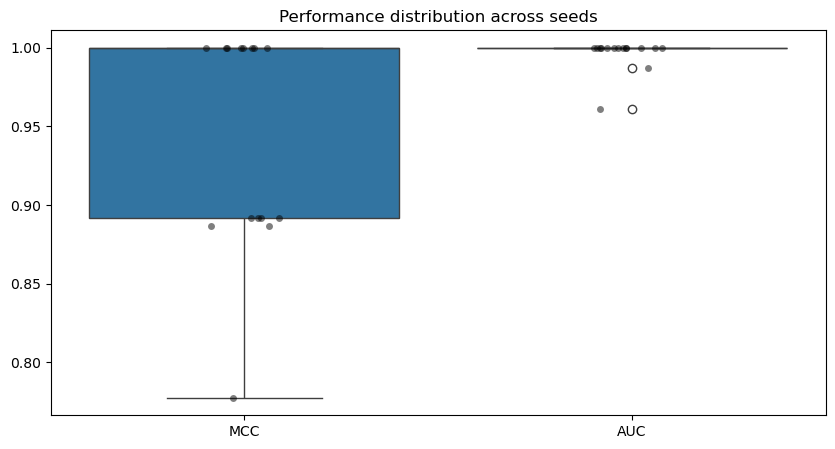

In [8]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=[all_test_mcc, all_test_auc])
sns.stripplot(data=[all_test_mcc, all_test_auc], color='black', alpha=0.5)
plt.xticks([0,1], ['MCC', 'AUC'])
plt.title("Performance distribution across seeds")
plt.show()

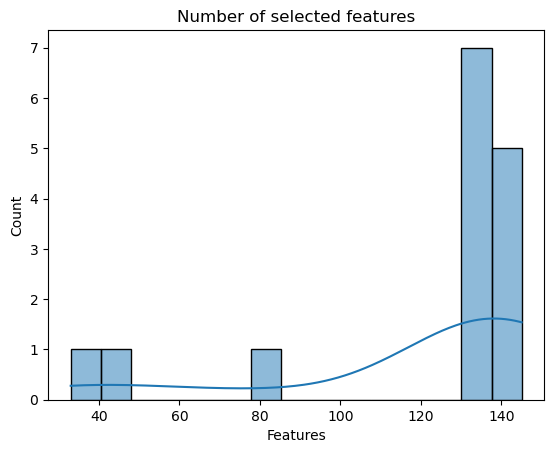

In [9]:
plt.figure()
sns.histplot(all_n_features, bins=15, kde=True)
plt.title("Number of selected features")
plt.xlabel("Features")
plt.show()

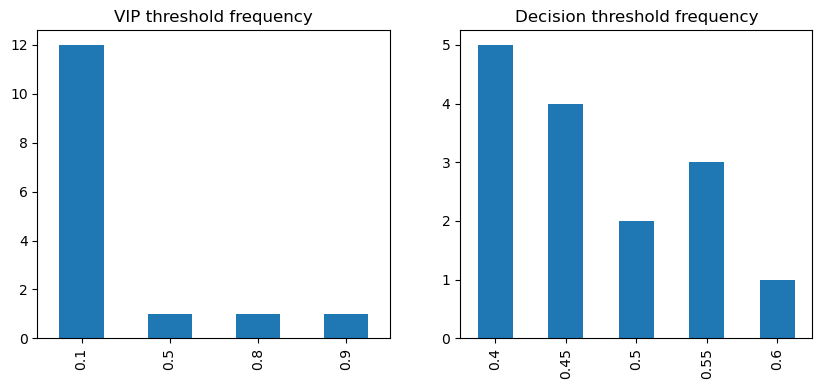

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
pd.Series(all_best_vip_thr).value_counts().sort_index().plot(kind='bar')
plt.title("VIP threshold frequency")

plt.subplot(1,2,2)
pd.Series(all_best_dec_thr).value_counts().sort_index().plot(kind='bar')
plt.title("Decision threshold frequency")

plt.show()